In [1]:
import os
from pathlib import Path
from dataclasses import dataclass
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (classification_report, roc_auc_score, average_precision_score)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

@dataclass
class CFG:
    # NOTEBOOK อยู่ D:\senior-project\src\... => ROOT = D:\senior-project
    ROOT: Path = Path.cwd().parents[0]
    NIH_DIR: Path = ROOT / "data" / "nih"
    CSV_PATH: Path = NIH_DIR / "Data_Entry_2017.csv"

    # images_* อยู่ใต้ NIH_DIR
    IMG_GLOB: str = "images_*/images/*.png"  # NIH

    TARGETS = ["Atelectasis","Cardiomegaly","Edema","Emphysema","Fibrosis"]
    N_PER_CLASS = 5000          # ต่อโรค
    N_NOFIND    = 5000          # No Finding
    SEED = 42

    IMG_SIZE = (224,224)        # CPU ช้า -> (192,192)
    BATCH = 16

    VAL_SPLIT = 0.2
    TEST_SPLIT = 0.2

    E_HEAD = 5
    E_FINE = 5
    LR1 = 1e-4
    LR2 = 1e-5

cfg = CFG()
cfg


KeyboardInterrupt: 

In [ ]:
def index_image_paths(nih_dir: Path, pattern: str):
    paths = list(nih_dir.glob(pattern))
    mp = {p.name: str(p) for p in paths}
    print("[INFO] Indexed images:", len(mp))
    return mp

def build_dataframe(cfg: CFG) -> pd.DataFrame:
    print("[INFO] Loading CSV:", cfg.CSV_PATH)
    df = pd.read_csv(cfg.CSV_PATH)

    # Map path
    mp = index_image_paths(cfg.NIH_DIR, cfg.IMG_GLOB)
    df["path"] = df["Image Index"].map(mp.get)
    df = df.dropna(subset=["path"]).reset_index(drop=True)

    # make 5 disease columns (multi-label)
    lbl = df["Finding Labels"].astype(str)
    for t in cfg.TARGETS:
        df[t] = lbl.str.contains(t, regex=False).astype("float32")

    # No Finding -> all-zero (ใน NIH: "No Finding")
    # เราไม่สร้างคอลัมน์ NoFinding แยก เพราะอยากได้ output 5 โรค (sigmoid) และ all-zero คือปกติ
    # แต่จะใช้ row ที่เป็น "No Finding" เป็น negative set
    df["is_nofinding"] = (lbl == "No Finding").astype("int")

    # keep only rows that are either: (a) have any of 5 diseases OR (b) No Finding
    any5 = df[cfg.TARGETS].sum(axis=1) > 0
    df = df[any5 | (df["is_nofinding"] == 1)].reset_index(drop=True)

    print("[INFO] Rows kept:", len(df))
    print("[INFO] No Finding rows:", int(df["is_nofinding"].sum()))
    print("[INFO] Pos counts:", df[cfg.TARGETS].sum().astype(int).to_dict())
    return df

df_all = build_dataframe(cfg)
df_all.head()


[INFO] Loading CSV: d:\senior-project\data\nih\Data_Entry_2017.csv
[INFO] Indexed images: 112120
[INFO] Rows kept: 79716
[INFO] No Finding rows: 60361
[INFO] Pos counts: {'Atelectasis': 11559, 'Cardiomegaly': 2776, 'Edema': 2303, 'Emphysema': 2516, 'Fibrosis': 1686}


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path,Atelectasis,Cardiomegaly,Edema,Emphysema,Fibrosis,is_nofinding
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,d:\senior-project\data\nih\images_001\images\0...,0.0,1.0,0.0,0.0,0.0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,d:\senior-project\data\nih\images_001\images\0...,0.0,1.0,0.0,1.0,0.0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,d:\senior-project\data\nih\images_001\images\0...,0.0,1.0,0.0,0.0,0.0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,d:\senior-project\data\nih\images_001\images\0...,0.0,0.0,0.0,0.0,0.0,1
4,00000005_000.png,No Finding,0,5,69,F,PA,2048,2500,0.168,0.168,NaN,d:\senior-project\data\nih\images_001\images\0...,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
def group_split(df: pd.DataFrame, cfg: CFG):
    gss = GroupShuffleSplit(test_size=cfg.TEST_SPLIT, random_state=cfg.SEED)
    tr_idx, te_idx = next(gss.split(df, groups=df["Patient ID"]))
    train_full = df.iloc[tr_idx].reset_index(drop=True)
    test_df    = df.iloc[te_idx].reset_index(drop=True)

    gss2 = GroupShuffleSplit(test_size=cfg.VAL_SPLIT, random_state=cfg.SEED)
    tr2_idx, va_idx = next(gss2.split(train_full, groups=train_full["Patient ID"]))
    train_df = train_full.iloc[tr2_idx].reset_index(drop=True)
    val_df   = train_full.iloc[va_idx].reset_index(drop=True)

    return train_df, val_df, test_df

def subsample_balanced(df: pd.DataFrame, cfg: CFG) -> pd.DataFrame:
    rng = np.random.RandomState(cfg.SEED)

    picked = []
    used_idx = set()

    # pick disease positives (allow multi-label; a row can contribute to multiple diseases)
    for t in cfg.TARGETS:
        sub = df[df[t] == 1.0].copy()
        sub = sub.sample(frac=1.0, random_state=cfg.SEED).reset_index(drop=True)

        take = sub.head(cfg.N_PER_CLASS)
        picked.append(take)
        used_idx.update(take.index.tolist())

    # pick No Finding (all-zero for targets AND label=="No Finding")
    nof = df[(df["is_nofinding"] == 1) & (df[cfg.TARGETS].sum(axis=1) == 0.0)].copy()
    nof = nof.sample(frac=1.0, random_state=cfg.SEED).reset_index(drop=True)
    picked.append(nof.head(cfg.N_NOFIND))

    out = pd.concat(picked, axis=0, ignore_index=True).sample(frac=1.0, random_state=cfg.SEED).reset_index(drop=True)
    return out

train_raw, val_raw, test_raw = group_split(df_all, cfg)

# ✅ ใช้ข้อมูลเต็ม (ลด overfit + เพิ่ม generalization)
train_df = train_raw.copy()
val_df   = val_raw.copy()
test_df  = test_raw.copy()


print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Train pos:", train_df[cfg.TARGETS].sum().astype(int).to_dict(), "NoFinding:", int(train_df["is_nofinding"].sum()))
print("Val pos  :", val_df[cfg.TARGETS].sum().astype(int).to_dict(), "NoFinding:", int(val_df["is_nofinding"].sum()))


Train: 16022 Val: 8292 Test: 15816
Train pos: {'Atelectasis': 5812, 'Cardiomegaly': 2215, 'Edema': 1715, 'Emphysema': 1854, 'Fibrosis': 1189} NoFinding: 5000
Val pos  : {'Atelectasis': 2105, 'Cardiomegaly': 452, 'Edema': 357, 'Emphysema': 520, 'Fibrosis': 332} NoFinding: 5000


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_png(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, cfg.IMG_SIZE, method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0
    return img

def augment(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.08)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return tf.clip_by_value(img, 0.0, 1.0)

def make_ds(df: pd.DataFrame, training=True):
    X = df["path"].astype(str).values
    Y = df[cfg.TARGETS].values.astype("float32")  # 5 outputs

    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if training:
        ds = ds.shuffle(min(len(df), 4096), seed=cfg.SEED, reshuffle_each_iteration=True)

    def _map(p, y):
        img = decode_png(p)
        if training:
            img = augment(img)
        return img, y

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(cfg.BATCH).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df, True)
val_ds   = make_ds(val_df, False)
test_ds  = make_ds(test_df, False)

next(iter(train_ds))[0].shape, next(iter(train_ds))[1].shape


(TensorShape([16, 224, 224, 3]), TensorShape([16, 5]))

In [ ]:
def build_model(name: str):
    name = name.lower()

    if name == "mobilenet":
        Base = tf.keras.applications.MobileNetV2
        preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
    elif name == "resnet":
        Base = tf.keras.applications.ResNet50
        preprocess = tf.keras.applications.resnet.preprocess_input
    elif name == "densenet":
        Base = tf.keras.applications.DenseNet121
        preprocess = tf.keras.applications.densenet.preprocess_input
    else:
        raise ValueError("name must be mobilenet/resnet/densenet")

    inp = tf.keras.Input(shape=(*cfg.IMG_SIZE, 3))
    x = tf.keras.layers.Rescaling(255.0)(inp)
    x = tf.keras.layers.Activation(preprocess)(x)

    backbone = Base(include_top=False, weights="imagenet", input_tensor=x)
    backbone._name = "backbone"  # สำคัญ: เรียกหาได้แน่นอน
    backbone.trainable = False

    x = backbone.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    out = tf.keras.layers.Dense(len(cfg.TARGETS), activation="sigmoid")(x)
    model = tf.keras.Model(inp, out, name=f"{name}_multilabel")
    return model

def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.AUC(curve="PR", multi_label=True, num_labels=len(cfg.TARGETS), name="auc_pr"),
            tf.keras.metrics.AUC(curve="ROC", multi_label=True, num_labels=len(cfg.TARGETS), name="auc_roc"),
        ],
    )

def unfreeze_last_pct(model, pct=0.2, keep_bn_frozen=True):
    """
    Unfreeze เฉพาะส่วนท้ายของ backbone แบบไม่พึ่งชื่อ layer
    - ถ้ามี layer ชื่อ 'backbone' ใช้อันนั้น
    - ไม่งั้นหา layer ที่เป็น tf.keras.Model ตัวสุดท้าย (มักคือ pretrained base)
    - ถ้าไม่เจอจริง ๆ จะ unfreeze ท้าย ๆ ของ model ทั้งตัวแทน
    """
    # 1) ใช้ชื่อ backbone ถ้ามี
    backbone = None
    for lyr in model.layers:
        if lyr.name == "backbone" and isinstance(lyr, tf.keras.Model):
            backbone = lyr
            break

    # 2) หา pretrained base แบบอัตโนมัติ (layer ที่เป็น Model ตัวสุดท้าย)
    if backbone is None:
        for lyr in reversed(model.layers):
            if isinstance(lyr, tf.keras.Model):
                backbone = lyr
                break

    # 3) fallback: ใช้ model ทั้งตัว
    target = backbone if backbone is not None else model

    target.trainable = True
    layers = target.layers
    n = len(layers)
    k = max(1, int(n * float(pct)))
    cut = n - k

    # freeze ส่วนต้น, unfreeze ส่วนท้าย
    for i, lyr in enumerate(layers):
        lyr.trainable = (i >= cut)

    # (แนะนำ) BN มักควร freeze เวลา fine-tune กันพัง/แกว่ง โดยเฉพาะ batch เล็ก
    if keep_bn_frozen:
        for lyr in layers:
            if isinstance(lyr, tf.keras.layers.BatchNormalization):
                lyr.trainable = False

    print(f"[unfreeze] target={target.name}  total_layers={n}  unfrozen_last={k}  pct={pct}")




=== TRAIN: mobilenet ===


C:\Users\ployhp\AppData\Local\Temp\ipykernel_26252\4142581163.py:20: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = Base(include_top=False, weights="imagenet", input_tensor=x)


Epoch 1/5
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 297s 293ms/step - auc_pr: 0.1815 - auc_roc: 0.5416 - loss: 0.7957 - val_auc_pr: 0.1457 - val_auc_roc: 0.6508 - val_loss: 0.3563 - learning_rate: 1.0000e-04
Epoch 2/5
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 295s 294ms/step - auc_pr: 0.2228 - auc_roc: 0.6184 - loss: 0.4770 - val_auc_pr: 0.1745 - val_auc_roc: 0.7013 - val_loss: 0.2788 - learning_rate: 1.0000e-04
Epoch 3/5
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 296s 296ms/step - auc_pr: 0.2569 - auc_roc: 0.6543 - loss: 0.4293 - val_auc_pr: 0.1943 - val_auc_roc: 0.7262 - val_loss: 0.2670 - learning_rate: 1.0000e-04
Epoch 4/5
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 308s 308ms/step - auc_pr: 0.2818 - auc_roc: 0.6822 - loss: 0.4108 - val_auc_pr: 0.2086 - val_auc_roc: 0.7404 - val_loss: 0.2605 - learning_rate: 1.0000e-04
Epoch 5/5
1002/1002 ━━━━━━━━━━━━━━━━━━━━ 324s 324ms/step - auc_pr: 0.3008 - auc_roc: 0.7081 - loss: 0.3914 - val_auc_pr: 0.2181 - val_auc_roc: 0.7490 - val_loss: 0.2588 - learning_rate: 1.0000e-04
[unfreeze] targ

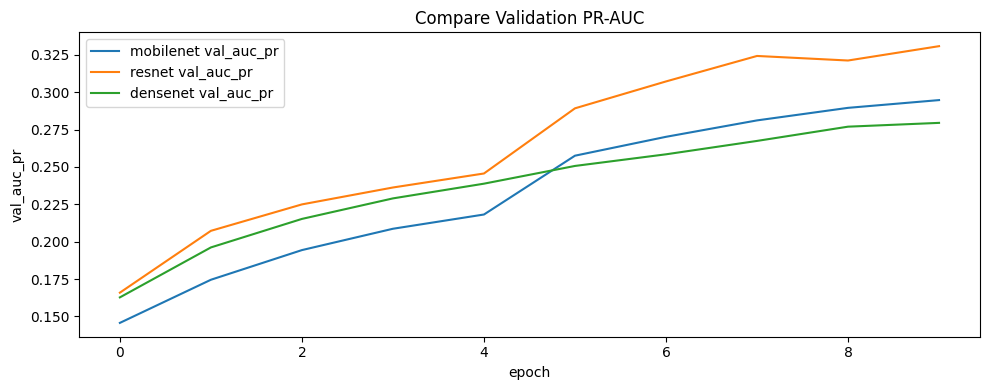

[DONE] Saved to: d:\senior-project\outputs\runs_multilabel


In [ ]:
RUNS_DIR = cfg.ROOT / "outputs" / "runs_multilabel"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

def train_one(name: str):
    model = build_model(name)

    cbs = [
        tf.keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max", patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc_pr", mode="max", factor=0.5, patience=1, min_lr=1e-6),
    ]

    compile_model(model, cfg.LR1)
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=cfg.E_HEAD, callbacks=cbs, verbose=1)

    unfreeze_last_pct(model, pct=0.2)
    compile_model(model, cfg.LR2)
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=cfg.E_FINE, callbacks=cbs, verbose=1)

    hist = {k: h1.history.get(k, []) + h2.history.get(k, []) for k in set(h1.history) | set(h2.history)}
    model.save(RUNS_DIR / f"{name}_final.keras")
    return model, hist

hist_all = {}
models = {}

for name in ["mobilenet", "resnet", "densenet"]:
    print("\n=== TRAIN:", name, "===")
    m, hist = train_one(name)
    models[name] = m
    hist_all[name] = hist

# plot compare val_auc_pr
plt.figure(figsize=(10,4))
for name,h in hist_all.items():
    if "val_auc_pr" in h:
        plt.plot(h["val_auc_pr"], label=f"{name} val_auc_pr")
plt.title("Compare Validation PR-AUC")
plt.xlabel("epoch")
plt.ylabel("val_auc_pr")
plt.legend()
plt.tight_layout()
plt.savefig(RUNS_DIR / "compare_val_auc_pr.png", dpi=200)
plt.show()

print("[DONE] Saved to:", RUNS_DIR)



=== EVAL: mobilenet ===


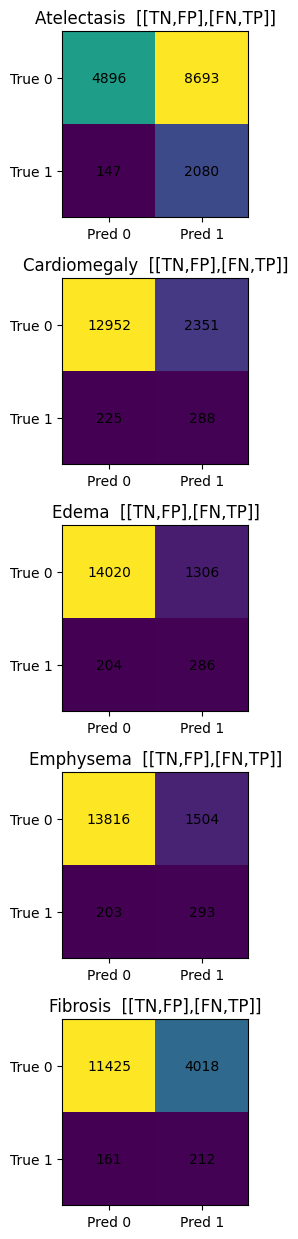


=== EVAL: resnet ===


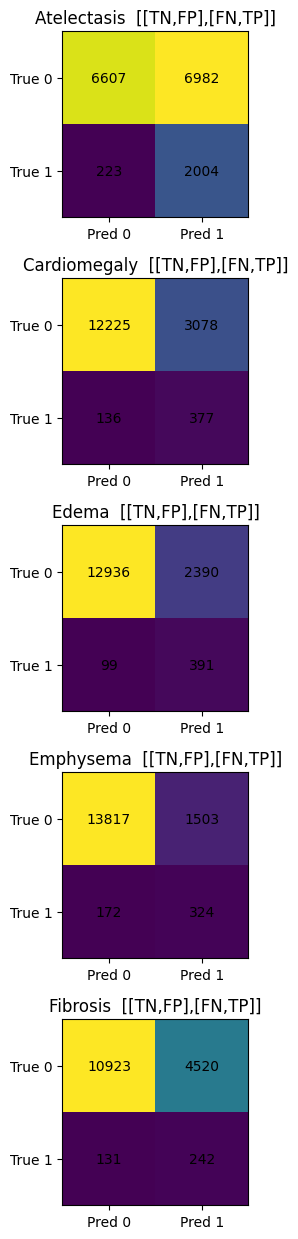


=== EVAL: densenet ===


In [ ]:
def collect_preds(model, ds):
    y_true, y_pred = [], []
    for xb, yb in ds:
        p = model.predict(xb, verbose=0)
        y_true.append(yb.numpy())
        y_pred.append(p)
    return np.vstack(y_true), np.vstack(y_pred)

def tune_thresholds(y_true, y_prob):
    # เลือก threshold ต่อโรค ที่ maximize F2 (เน้น recall มากกว่า precision)
    thr = []
    for k in range(y_true.shape[1]):
        best_t, best_f2 = 0.5, -1
        for t in np.linspace(0.05, 0.95, 19):
            y_hat = (y_prob[:,k] >= t).astype(int)
            tp = ((y_hat==1) & (y_true[:,k]==1)).sum()
            fp = ((y_hat==1) & (y_true[:,k]==0)).sum()
            fn = ((y_hat==0) & (y_true[:,k]==1)).sum()
            prec = tp / (tp+fp+1e-9)
            rec  = tp / (tp+fn+1e-9)
            f2 = (5*prec*rec) / (4*prec + rec + 1e-9)  # F2
            if f2 > best_f2:
                best_f2 = f2
                best_t = float(t)
        thr.append(best_t)
    return np.array(thr, dtype=np.float32)

def per_class_confusion(y_true_bin, y_pred_bin):
    mats = {}
    for i,t in enumerate(cfg.TARGETS):
        yt = y_true_bin[:,i].astype(int)
        yp = y_pred_bin[:,i].astype(int)
        tp = int(((yp==1)&(yt==1)).sum())
        tn = int(((yp==0)&(yt==0)).sum())
        fp = int(((yp==1)&(yt==0)).sum())
        fn = int(((yp==0)&(yt==1)).sum())
        mats[t] = {"TP":tp,"TN":tn,"FP":fp,"FN":fn}
    return mats

def plot_confusion_heatmaps(mats, out_png):
    # heatmap ต่อโรค: [[TN,FP],[FN,TP]]
    n = len(cfg.TARGETS)
    plt.figure(figsize=(12, 2.5*n))
    for i,t in enumerate(cfg.TARGETS, start=1):
        tn,fp,fn,tp = mats[t]["TN"], mats[t]["FP"], mats[t]["FN"], mats[t]["TP"]
        M = np.array([[tn, fp],[fn, tp]])
        plt.subplot(n,1,i)
        plt.imshow(M)
        plt.title(f"{t}  [[TN,FP],[FN,TP]]")
        for r in range(2):
            for c in range(2):
                plt.text(c, r, str(M[r,c]), ha="center", va="center")
        plt.xticks([0,1], ["Pred 0","Pred 1"])
        plt.yticks([0,1], ["True 0","True 1"])
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.show()

results = {}

for name, model in models.items():
    print("\n=== EVAL:", name, "===")
    yv_true, yv_prob = collect_preds(model, val_ds)
    thr = tune_thresholds(yv_true, yv_prob)

    yt_true, yt_prob = collect_preds(model, test_ds)
    yt_pred = (yt_prob >= thr[None,:]).astype(int)

    # metrics
    roc = roc_auc_score(yt_true, yt_prob, average="macro")
    pr  = average_precision_score(yt_true, yt_prob, average="macro")

    report = classification_report(
        yt_true.astype(int),
        yt_pred.astype(int),
        target_names=cfg.TARGETS,
        digits=4,
        zero_division=0
    )

    mats = per_class_confusion(yt_true, yt_pred)

    # save
    (RUNS_DIR / f"{name}_report.txt").write_text(
        f"MODEL: {name}\n"
        f"ROC_AUC_macro: {roc:.4f}\n"
        f"PR_AUC_macro: {pr:.4f}\n"
        f"Thresholds: {dict(zip(cfg.TARGETS, thr.tolist()))}\n\n"
        f"{report}\n\n"
        f"Per-class confusion (TP,TN,FP,FN):\n{mats}\n",
        encoding="utf-8"
    )

    plot_confusion_heatmaps(mats, RUNS_DIR / f"{name}_confusions.png")

    results[name] = {"roc_auc_macro": roc, "pr_auc_macro": pr, "thresholds": thr, "conf": mats}

print("[DONE] reports saved in:", RUNS_DIR)


In [ ]:
def find_last_conv_layer(model):
    # หา conv สุดท้ายใน backbone
    backbone = model.get_layer("backbone")
    for lyr in reversed(backbone.layers):
        if isinstance(lyr, tf.keras.layers.Conv2D):
            return lyr.name
    # fallback: หาในทั้งโมเดล
    for lyr in reversed(model.layers):
        if isinstance(lyr, tf.keras.layers.Conv2D):
            return lyr.name
    raise ValueError("No Conv2D found")

def gradcam_one(model, img_path):
    img0 = decode_png(tf.constant(img_path))
    img = tf.expand_dims(img0, 0)

    last_conv_name = find_last_conv_layer(model)
    last_conv = model.get_layer(last_conv_name)

    grad_model = tf.keras.Model([model.inputs], [last_conv.output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img, training=False)
        score = tf.reduce_max(preds, axis=1)  # focus strongest disease
    grads = tape.gradient(score, conv_out)
    w = tf.reduce_mean(grads, axis=(1,2))
    cam = tf.reduce_sum(conv_out[0] * w[0][None,None,:], axis=-1)
    cam = tf.maximum(cam, 0) / (tf.reduce_max(cam) + 1e-8)
    cam = tf.image.resize(cam[...,None], cfg.IMG_SIZE).numpy().squeeze()
    return img0.numpy(), cam, preds.numpy()[0]

def save_gradcam_png(img, cam, out_png):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img); plt.axis("off"); plt.title("Original")
    plt.subplot(1,2,2); plt.imshow(img); plt.imshow(cam, alpha=0.45); plt.axis("off"); plt.title("Grad-CAM")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.show()

# ===== Predict: % risk ต่อรูป (เลือกโมเดลที่ดีที่สุดจาก PR-AUC หรือจากผลที่คุณต้องการ)
best_name = max(results.keys(), key=lambda k: results[k]["pr_auc_macro"])
best_model = models[best_name]
best_thr = results[best_name]["thresholds"]

print("Best by PR-AUC:", best_name)

def predict_one_image_percent(model, img_path):
    img = decode_png(tf.constant(img_path))
    p = model.predict(tf.expand_dims(img,0), verbose=0)[0]
    out = {d: float(p[i]*100) for i,d in enumerate(cfg.TARGETS)}
    top = max(out, key=out.get)
    return out, top

# test folder ของคุณ (รวมทุกโรคปนกัน)
TEST_FOLDER = cfg.NIH_DIR / "test"  # <-- แก้ตามโฟลเดอร์จริงของคุณ
test_imgs = sorted(list(TEST_FOLDER.glob("*.png")))

print("Test images found:", len(test_imgs))
for p in test_imgs[:5]:
    probs, top = predict_one_image_percent(best_model, str(p))
    print(p.name, "=> TOP:", top, "|", {k: f"{v:.2f}%" for k,v in probs.items()})

# Grad-CAM ตัวอย่าง 1 รูป
if len(test_imgs) > 0:
    img, cam, preds = gradcam_one(best_model, str(test_imgs[0]))
    save_gradcam_png(img, cam, RUNS_DIR / f"gradcam_{best_name}_sample.png")
